In [1]:
import sys
import subprocess

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--quiet", "--force-reinstall", "--no-cache-dir",
    "torch==2.7.1",
    "torchvision==0.22.1",
    "torchaudio==2.7.1",
    "transformers==4.52.4",
    "accelerate==1.7.0",
    "datasets==3.6.0",
    "evaluate==0.4.3",
    "tokenizers==0.21.1"
])

KeyboardInterrupt: 

In [1]:
import sys
import transformers
import accelerate
import datasets
import torch

print("Python executable:", sys.executable)
print("Transformers:", transformers.__version__, transformers.__file__)
print("Accelerate:", accelerate.__version__, accelerate.__file__)
print("Datasets:", datasets.__version__)
print("Torch:", torch.__version__)

Python executable: /usr/bin/python3
Transformers: 4.52.4 /usr/local/lib/python3.12/dist-packages/transformers/__init__.py
Accelerate: 1.7.0 /usr/local/lib/python3.12/dist-packages/accelerate/__init__.py
Datasets: 3.6.0
Torch: 2.7.1+cu126


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset
from google.colab import drive

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Original sizes:
{'train': 2763, 'val': 115, 'test': 2765}

Original Step 1 distribution:
          Train  Validation  Test
anger       333          16   322
fear       1610          62  1543
joy         674          31   670
sadness     875          34   880
surprise    839          31   799


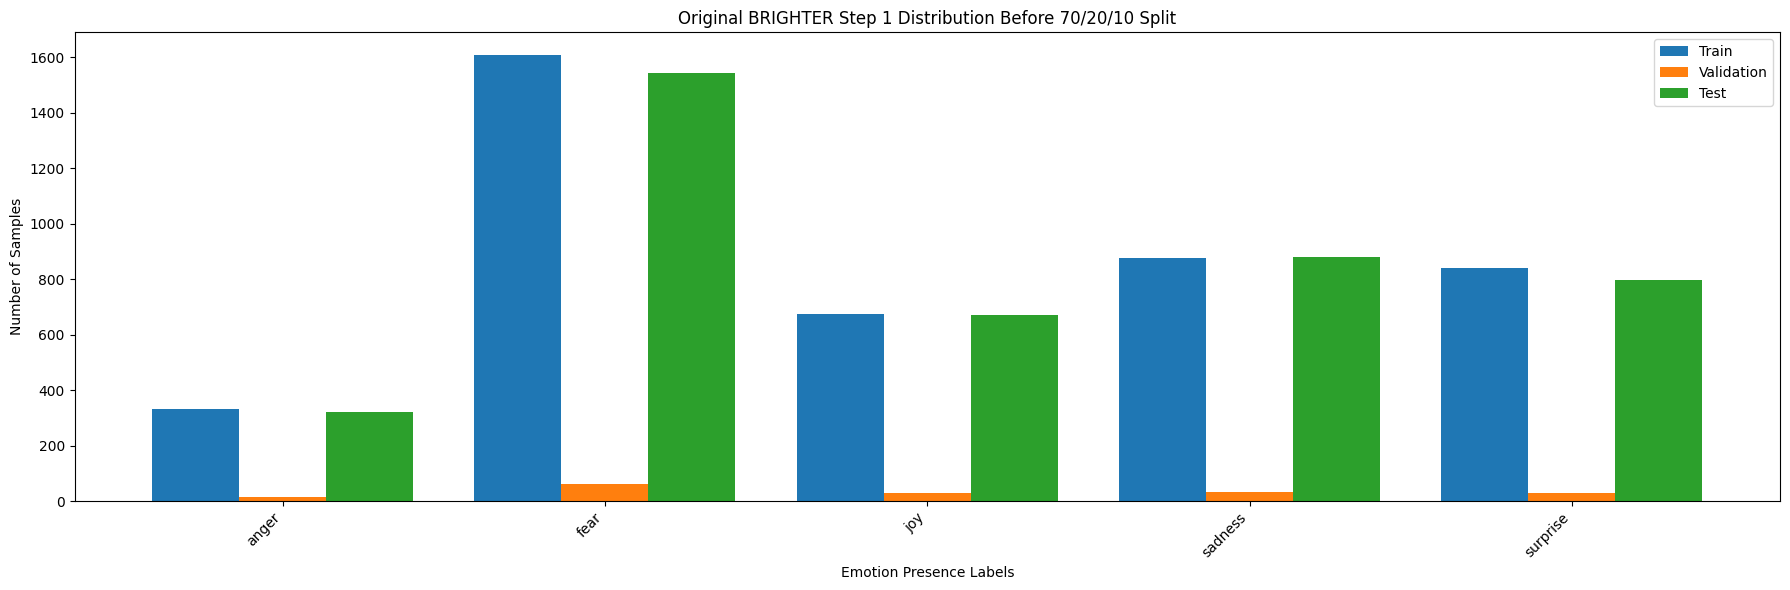


Original Step 2 distribution:
            Train  Validation  Test
anger_1       207           6   188
anger_2        88           9    97
anger_3        38           1    37
fear_1        856          36   832
fear_2        546          19   486
fear_3        208           7   225
joy_1         449          20   438
joy_2         161          10   176
joy_3          64           1    56
sadness_1     505          21   524
sadness_2     246           9   224
sadness_3     124           4   132
surprise_1    588          19   553
surprise_2    215          12   209
surprise_3     36           0    37


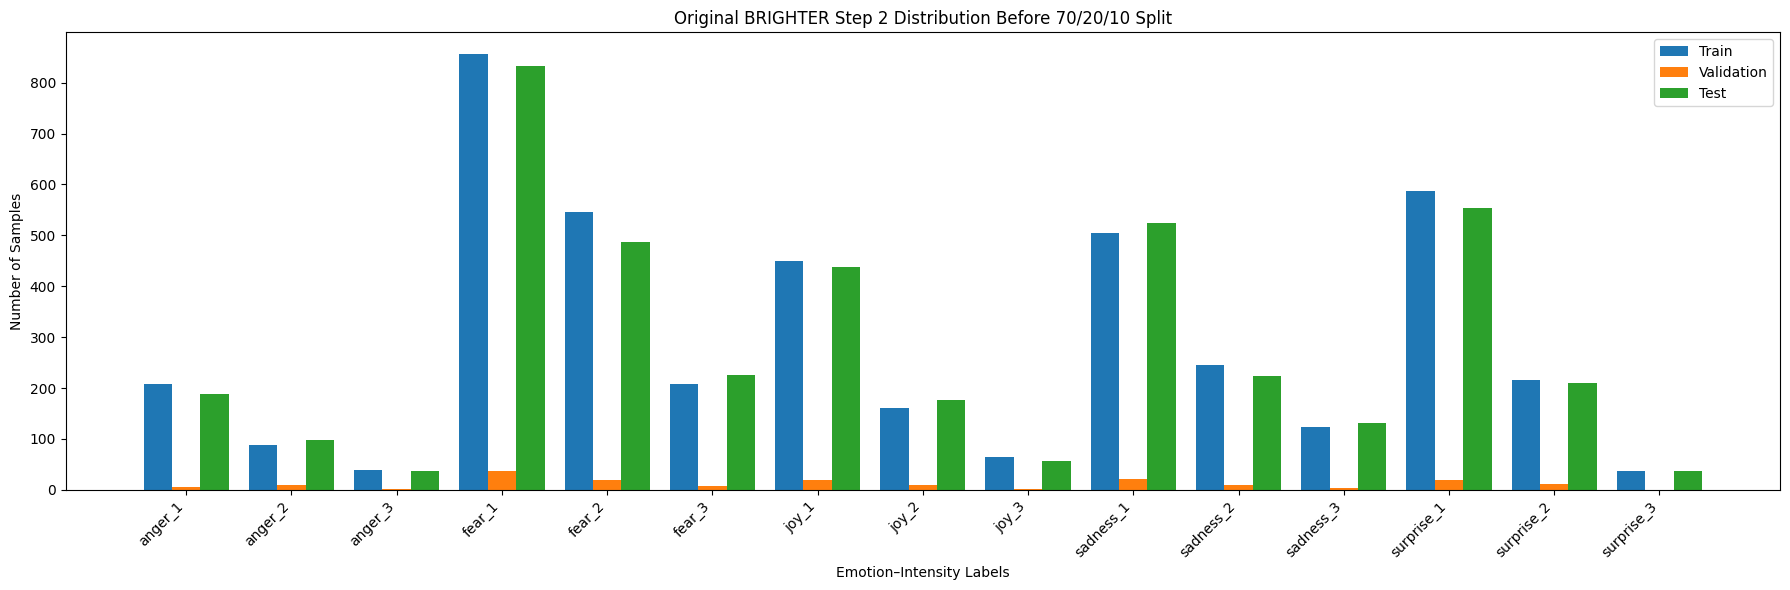


New split sizes:
{'train': 3950, 'val': 1128, 'test': 565}

Step 1 distribution after 70/20/10 split:
          Train  Validation  Test
anger       463         148    60
fear       2278         629   308
joy         969         272   134
sadness    1251         364   174
surprise   1151         338   180


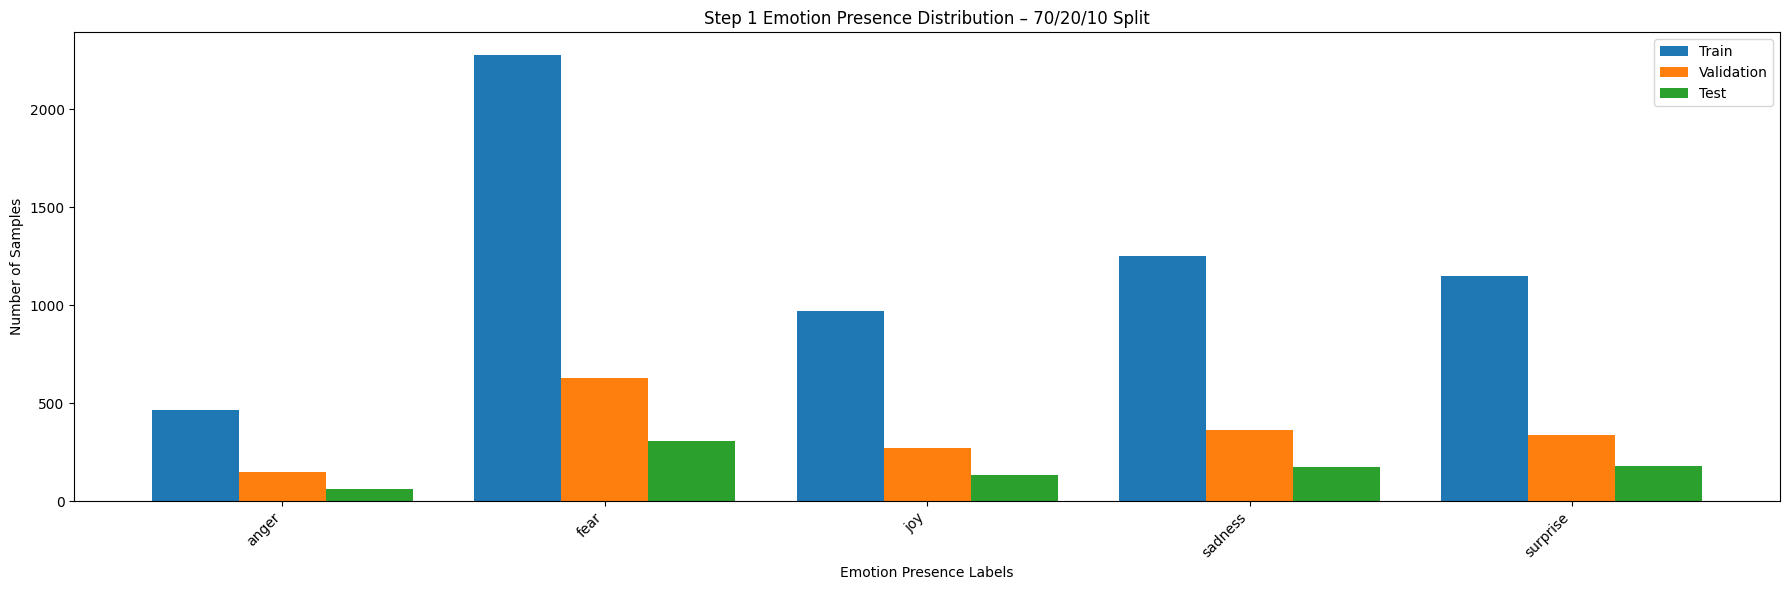


Step 2 distribution after 70/20/10 split:
            Train  Validation  Test
anger_1       270          95    36
anger_2       139          40    15
anger_3        54          13     9
fear_1       1235         330   159
fear_2        744         208    99
fear_3        299          91    50
joy_1         644         172    91
joy_2         246          70    31
joy_3          79          30    12
sadness_1     742         209    99
sadness_2     323         103    53
sadness_3     186          52    22
surprise_1    803         236   121
surprise_2    300          83    53
surprise_3     48          19     6


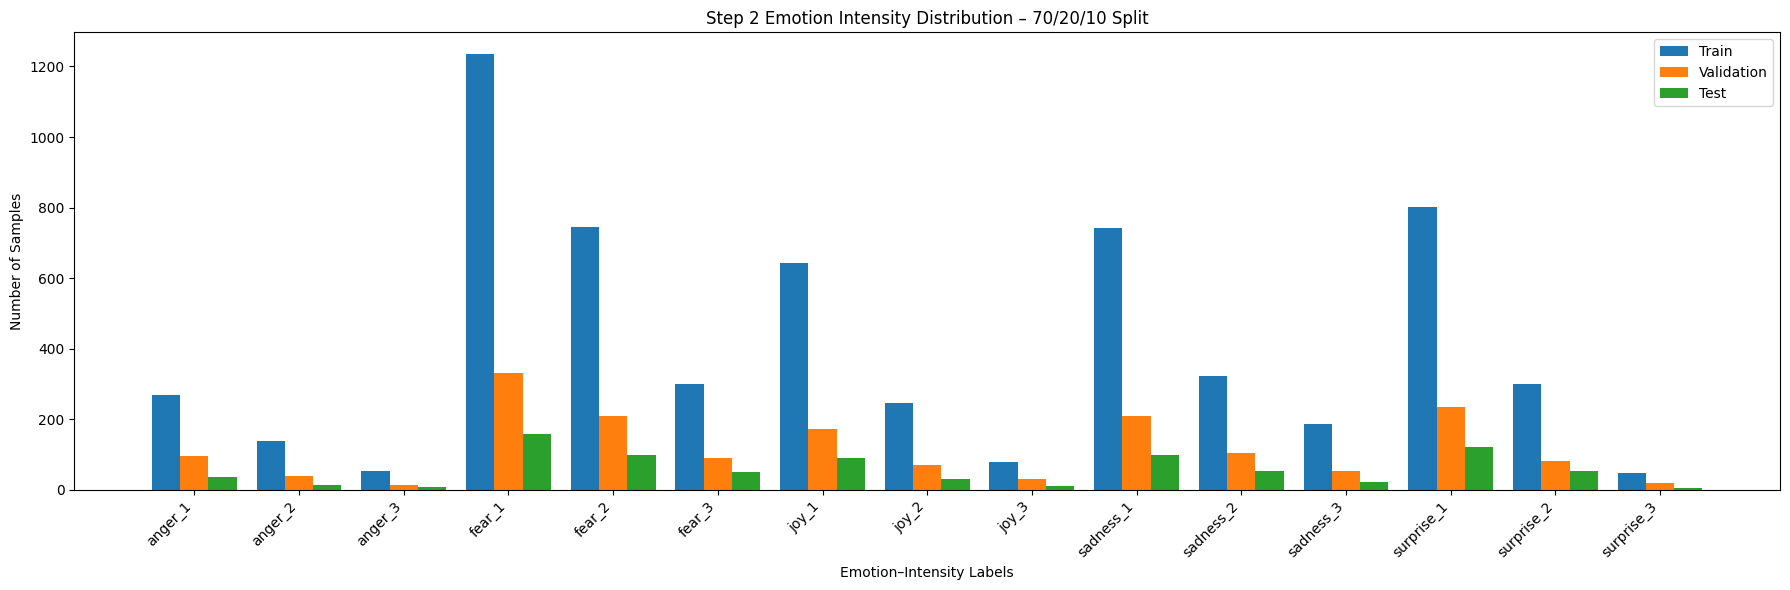


Step 1 sentence logs saved:
/content/drive/MyDrive/TwoStep_step1_train_sentence_log.csv
/content/drive/MyDrive/TwoStep_step1_val_sentence_log.csv
/content/drive/MyDrive/TwoStep_step1_test_sentence_log.csv

Step 2 sentence logs saved:
/content/drive/MyDrive/TwoStep_step2_train_sentence_log.csv
/content/drive/MyDrive/TwoStep_step2_val_sentence_log.csv
/content/drive/MyDrive/TwoStep_step2_test_sentence_log.csv

Step 1 sample:
   sentence_id                                           sentence  \
0            0              " She was slapping at air, screaming.   
1            1  I think it's because I've got one of those lit...   
2            2  To this day, I still don't know the reasoning ...   
3            3  I closed my eyes and listened to the silence w...   
4            4                          Except it was in the sky.   

                      true_labels  
0         fear, sadness, surprise  
1                     anger, fear  
2  anger, fear, sadness, surprise  
3            

In [3]:
# =========================================================
# GOOGLE DRIVE
# =========================================================

drive.mount("/content/drive")

STEP1_TRAIN_LOG = "/content/drive/MyDrive/TwoStep_step1_train_sentence_log.csv"
STEP1_VAL_LOG   = "/content/drive/MyDrive/TwoStep_step1_val_sentence_log.csv"
STEP1_TEST_LOG  = "/content/drive/MyDrive/TwoStep_step1_test_sentence_log.csv"

STEP2_TRAIN_LOG = "/content/drive/MyDrive/TwoStep_step2_train_sentence_log.csv"
STEP2_VAL_LOG   = "/content/drive/MyDrive/TwoStep_step2_val_sentence_log.csv"
STEP2_TEST_LOG  = "/content/drive/MyDrive/TwoStep_step2_test_sentence_log.csv"


# =========================================================
# CONFIGURATION
# =========================================================

SEED = 42

EMOTIONS = ["anger", "fear", "joy", "sadness", "surprise"]

INTENSITY_COLUMNS = [
    f"{emotion}_intensity"
    for emotion in EMOTIONS
]

LEVELS = [1, 2, 3]

LABELS = [
    f"{emotion}_{level}"
    for emotion in EMOTIONS
    for level in LEVELS
]


# =========================================================
# LOAD DATASET
# =========================================================

train_data = load_dataset(
    "brighter-dataset/BRIGHTER-emotion-intensities",
    "eng",
    split="train"
)

val_data = load_dataset(
    "brighter-dataset/BRIGHTER-emotion-intensities",
    "eng",
    split="dev"
)

test_data = load_dataset(
    "brighter-dataset/BRIGHTER-emotion-intensities",
    "eng",
    split="test"
)

train_df = train_data.to_pandas()
val_df   = val_data.to_pandas()
test_df  = test_data.to_pandas()

print("Original sizes:")
print({
    "train": len(train_df),
    "val": len(val_df),
    "test": len(test_df)
})


# =========================================================
# PREPARE TWO-STEP DATA
# =========================================================

def prepare_two_step_data(df):
    df = df.copy()

    if "disgust" in df.columns:
        df = df.drop(columns=["disgust"])

    # Preserve original intensity values
    for emotion in EMOTIONS:
        df[f"{emotion}_intensity"] = df[emotion].astype(int)

    # Convert original emotion columns to presence labels
    for emotion in EMOTIONS:
        df[emotion] = (
            df[f"{emotion}_intensity"] > 0
        ).astype(int)

    return df


train_two = prepare_two_step_data(train_df)
val_two   = prepare_two_step_data(val_df)
test_two  = prepare_two_step_data(test_df)


# =========================================================
# DISTRIBUTION FUNCTIONS
# =========================================================

def get_intensity_distribution(df):
    return pd.Series({
        f"{emotion}_{level}": (
            df[f"{emotion}_intensity"] == level
        ).sum()
        for emotion in EMOTIONS
        for level in LEVELS
    })


def plot_distribution(
    train_counts,
    val_counts,
    test_counts,
    labels,
    title,
    xlabel
):
    x = np.arange(len(labels))
    width = 0.27

    plt.figure(figsize=(18, 6))

    plt.bar(
        x - width,
        train_counts,
        width,
        label="Train"
    )

    plt.bar(
        x,
        val_counts,
        width,
        label="Validation"
    )

    plt.bar(
        x + width,
        test_counts,
        width,
        label="Test"
    )

    plt.xticks(
        x,
        labels,
        rotation=45,
        ha="right"
    )

    plt.xlabel(xlabel)
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# ORIGINAL DISTRIBUTION BEFORE 70/20/10 SPLIT
# =========================================================

# Step 1: emotion presence
original_step1_distribution = pd.DataFrame({
    "Train": train_two[EMOTIONS].sum(),
    "Validation": val_two[EMOTIONS].sum(),
    "Test": test_two[EMOTIONS].sum()
})

print("\nOriginal Step 1 distribution:")
print(original_step1_distribution)

plot_distribution(
    original_step1_distribution["Train"],
    original_step1_distribution["Validation"],
    original_step1_distribution["Test"],
    EMOTIONS,
    "Original BRIGHTER Step 1 Distribution Before 70/20/10 Split",
    "Emotion Presence Labels"
)


# Step 2: emotion intensities
original_step2_distribution = pd.DataFrame({
    "Train": get_intensity_distribution(train_two),
    "Validation": get_intensity_distribution(val_two),
    "Test": get_intensity_distribution(test_two)
})

print("\nOriginal Step 2 distribution:")
print(original_step2_distribution)

plot_distribution(
    original_step2_distribution["Train"],
    original_step2_distribution["Validation"],
    original_step2_distribution["Test"],
    LABELS,
    "Original BRIGHTER Step 2 Distribution Before 70/20/10 Split",
    "Emotion–Intensity Labels"
)


# =========================================================
# TRUE 70/20/10 SPLIT
# =========================================================

full_df = pd.concat(
    [train_two, val_two, test_two],
    ignore_index=True
)

full_df = full_df[
    ["text"] + EMOTIONS + INTENSITY_COLUMNS
]

full_df = full_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

n = len(full_df)

train_end = int(0.70 * n)
val_end   = int(0.90 * n)

train_split = full_df[
    :train_end
].reset_index(drop=True)

val_split = full_df[
    train_end:val_end
].reset_index(drop=True)

test_split = full_df[
    val_end:
].reset_index(drop=True)

print("\nNew split sizes:")
print({
    "train": len(train_split),
    "val": len(val_split),
    "test": len(test_split)
})


# =========================================================
# DISTRIBUTION AFTER 70/20/10 SPLIT
# =========================================================

# Step 1 distribution
step1_distribution = pd.DataFrame({
    "Train": train_split[EMOTIONS].sum(),
    "Validation": val_split[EMOTIONS].sum(),
    "Test": test_split[EMOTIONS].sum()
})

print("\nStep 1 distribution after 70/20/10 split:")
print(step1_distribution)

plot_distribution(
    step1_distribution["Train"],
    step1_distribution["Validation"],
    step1_distribution["Test"],
    EMOTIONS,
    "Step 1 Emotion Presence Distribution – 70/20/10 Split",
    "Emotion Presence Labels"
)


# Step 2 distribution
step2_distribution = pd.DataFrame({
    "Train": get_intensity_distribution(train_split),
    "Validation": get_intensity_distribution(val_split),
    "Test": get_intensity_distribution(test_split)
})

print("\nStep 2 distribution after 70/20/10 split:")
print(step2_distribution)

plot_distribution(
    step2_distribution["Train"],
    step2_distribution["Validation"],
    step2_distribution["Test"],
    LABELS,
    "Step 2 Emotion Intensity Distribution – 70/20/10 Split",
    "Emotion–Intensity Labels"
)


# =========================================================
# STEP 1 DATA: EMOTION PRESENCE
# =========================================================

train_step1_df = train_split[
    ["text"] + EMOTIONS
].copy()

val_step1_df = val_split[
    ["text"] + EMOTIONS
].copy()

test_step1_df = test_split[
    ["text"] + EMOTIONS
].copy()


# =========================================================
# STEP 2 DATA: INTENSITY PREDICTION
# =========================================================

train_step2_df = train_split[
    ["text"] + INTENSITY_COLUMNS
].copy()

val_step2_df = val_split[
    ["text"] + INTENSITY_COLUMNS
].copy()

test_step2_df = test_split[
    ["text"] + INTENSITY_COLUMNS
].copy()


# =========================================================
# SENTENCE-WISE STEP 1 LOGS
# =========================================================

def create_step1_sentence_log(df):
    rows = []

    for sentence_id, row in df.iterrows():

        true_labels = [
            emotion
            for emotion in EMOTIONS
            if int(row[emotion]) == 1
        ]

        rows.append({
            "sentence_id": sentence_id,
            "sentence": row["text"],
            "true_labels": (
                ", ".join(true_labels)
                if true_labels
                else "No Emotion"
            )
        })

    return pd.DataFrame(rows)


train_step1_log = create_step1_sentence_log(train_split)
val_step1_log   = create_step1_sentence_log(val_split)
test_step1_log  = create_step1_sentence_log(test_split)


# =========================================================
# SENTENCE-WISE STEP 2 LOGS
# =========================================================

def create_step2_sentence_log(df):
    rows = []

    for sentence_id, row in df.iterrows():

        true_labels = []

        for emotion in EMOTIONS:
            intensity = int(
                row[f"{emotion}_intensity"]
            )

            if intensity > 0:
                true_labels.append(
                    f"{emotion}_{intensity}"
                )

        rows.append({
            "sentence_id": sentence_id,
            "sentence": row["text"],
            "true_labels": (
                ", ".join(true_labels)
                if true_labels
                else "No Emotion"
            )
        })

    return pd.DataFrame(rows)


train_step2_log = create_step2_sentence_log(train_split)
val_step2_log   = create_step2_sentence_log(val_split)
test_step2_log  = create_step2_sentence_log(test_split)


# =========================================================
# SAVE LOGS TO GOOGLE DRIVE
# =========================================================

train_step1_log.to_csv(STEP1_TRAIN_LOG, index=False)
val_step1_log.to_csv(STEP1_VAL_LOG, index=False)
test_step1_log.to_csv(STEP1_TEST_LOG, index=False)

train_step2_log.to_csv(STEP2_TRAIN_LOG, index=False)
val_step2_log.to_csv(STEP2_VAL_LOG, index=False)
test_step2_log.to_csv(STEP2_TEST_LOG, index=False)

print("\nStep 1 sentence logs saved:")
print(STEP1_TRAIN_LOG)
print(STEP1_VAL_LOG)
print(STEP1_TEST_LOG)

print("\nStep 2 sentence logs saved:")
print(STEP2_TRAIN_LOG)
print(STEP2_VAL_LOG)
print(STEP2_TEST_LOG)

print("\nStep 1 sample:")
print(train_step1_log.head())

print("\nStep 2 sample:")
print(train_step2_log.head())